# Exercise 01: Text Generation from a Real Corpus
## AIAT 124 - Generative AI

---

## Learning Objectives

In this exercise, you will:
- Turn a real text corpus into a character vocabulary and next-character training windows
- Build and train the character-level language model from lesson 01 (Embedding → LSTM → Linear)
- Generate text with temperature sampling and compare two temperatures on the same seed
- Evaluate the generator honestly: perplexity against an untrained baseline and a held-out split, plus a stated sample-level metric

---

## Real-World Context

A sports-media start-up wants an autocomplete for its hockey writers. Before anyone mentions a
GPT-sized model, the team needs a small prototype it fully understands: trained on real posts people
wrote about hockey, shown at a cautious and at an adventurous decoding setting, and reported with
numbers that would survive a sceptical reviewer.

---

## Data used in this exercise

**Real text, offline.** 600 posts from the `rec.sport.hockey` group of 20 Newsgroups — the same
corpus family as lesson 01, a different group — read from scikit-learn's local cache
(`~/scikit_learn_data`). The setup cell passes `download_if_missing=False`, so nothing is fetched from
the network; if the cache is missing it stops with a message saying what to do.

---

## How to work

Each task has a `# YOUR CODE HERE` scaffold ending in `raise NotImplementedError`, followed by a
**gate cell** of `assert` checks. **The gates fail by design until the task above them is filled in:**
a red `NotImplementedError` (or an `AssertionError` saying an earlier gate must pass first) under a
gate you have not reached yet is the expected starting state of this notebook, not a fault. Fill a
task, re-run its gate, and move on when it prints `Gate N passed`. The worked example at the bottom
runs on its own and needs none of your code.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- 600 real `rec.sport.hockey` posts from the cached 20 Newsgroups corpus (first 30,000 characters after normalisation)
- PyTorch (`nn.Embedding`, `nn.LSTM`, `nn.Linear`, Adam, cross-entropy), NumPy, Matplotlib

**Outputs:** What you'll see when you run the cells

- A vocabulary and window count; a training and a held-out loss per epoch; two 300-character samples from the same seed at T = 0.5 and T = 1.2; a table of perplexities and in-vocabulary word rates
- Four `Gate N passed` lines once the tasks are complete, and the bigram baseline's numbers from the worked example

---


In [1]:
# Setup: everything the tasks need is imported here — run this first.
# The corpus is REAL text: 600 posts from the rec.sport.hockey group of 20 Newsgroups, read
# from scikit-learn's local cache (~/scikit_learn_data). download_if_missing=False means this
# cell never touches the network — if the cache is absent it stops with a clear message.
import math, re
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups

torch.manual_seed(42); np.random.seed(42)

try:
    news = fetch_20newsgroups(subset="train", categories=["rec.sport.hockey"],
                              remove=("headers", "footers", "quotes"),   # keep the prose people wrote
                              download_if_missing=False)
except OSError as exc:   # scikit-learn raises OSError when the cached copy is missing
    raise RuntimeError("20 Newsgroups is not in scikit-learn's cache (~/scikit_learn_data). "
                       "Run Unit 2 example 01 once while online, then come back here.") from exc

raw = " ".join(news.data)
# Same light normalisation as lesson 01: lowercase; keep letters, digits, space, '.' and ','.
# A small character set is what lets a small LSTM learn something on a CPU in a minute.
text = re.sub(r"\s+", " ", re.sub(r"[^a-z0-9 .,]", " ", raw.lower())).strip()[:30_000]
SEQ_LEN = 30          # characters of context the model sees when predicting the next one

print(f"Real corpus: {len(news.data)} rec.sport.hockey posts -> first {len(text):,} characters used")
print(f"Sample: {text[1000:1160]!r}")
print(f"Context window: {SEQ_LEN} characters")


Real corpus: 600 rec.sport.hockey posts -> first 30,000 characters used
Sample: ' problem the one they ve had for a number of years i tried to point out. spirit, mental preparedness, will to win, whatever you want to call it, it s missing wh'
Context window: 30 characters


## Task 1: Vocabulary and Training Windows (20 points)

Lesson 01 turned text into numbers with a character "tokenizer" and sliced it into windows. Do the same here.

**Requirements:**
- `build_vocab(text)` returns `(chars, c2i, i2c)`: the **sorted** list of distinct characters, a character→id dictionary and its inverse
- `make_windows(encoded, seq_len)` returns `(X, y)` as `torch.long` tensors: row `i` of `X` is `encoded[i : i + seq_len]` and `y[i]` is `encoded[i + seq_len]`, for every `i` that fits
- The gate splits the encoded text **by position** (first 80% train, last 20% held out) before calling `make_windows` on each part — read its comment for why shuffling here would be a mistake


In [2]:
# TODO Task 1: the "tokenizer" and the dataset. Replace each `raise NotImplementedError`.
def build_vocab(text):
    """Return (chars, c2i, i2c): the sorted distinct characters of `text` and both lookups."""
    # YOUR CODE HERE
    raise NotImplementedError("Task 1 TODO: build_vocab is not implemented yet")


def make_windows(encoded, seq_len):
    """Every seq_len-character window predicts the character that follows it.
    Return (X, y) as LongTensors with shapes (n, seq_len) and (n,), n = len(encoded) - seq_len."""
    # YOUR CODE HERE
    raise NotImplementedError("Task 1 TODO: make_windows is not implemented yet")


print("Functions defined — run the gate cell below.")


Functions defined — run the gate cell below.


In [3]:
# --- Gate 1 (fails by design until Task 1 is filled in) ---
chars, c2i, i2c = build_vocab(text)
V = len(chars)
encoded = [c2i[c] for c in text]
# Split by POSITION, not by shuffling: the last 20% is prose the model never trains on, which
# is the only way a held-out number in Task 4 means anything.
split = int(0.8 * len(encoded))
train_ids, val_ids = encoded[:split], encoded[split:]
X_tr, y_tr = make_windows(train_ids, SEQ_LEN)
X_val, y_val = make_windows(val_ids, SEQ_LEN)

assert chars == sorted(set(text)), "chars must be the sorted distinct characters of the text"
assert all(i2c[c2i[c]] == c for c in chars), "c2i and i2c must be inverses of each other"
assert X_tr.dtype == torch.long and y_tr.dtype == torch.long, "windows must be LongTensors"
assert X_tr.shape == (len(train_ids) - SEQ_LEN, SEQ_LEN), f"X_tr shape {tuple(X_tr.shape)} is wrong"
assert y_tr.shape == (len(train_ids) - SEQ_LEN,), f"y_tr shape {tuple(y_tr.shape)} is wrong"
assert torch.equal(X_tr[1, :-1], X_tr[0, 1:]), "consecutive windows must overlap by seq_len - 1 characters"
assert int(y_tr[0]) == train_ids[SEQ_LEN], "y[i] must be the character right after window i"
print(f"Gate 1 passed: vocabulary {V} characters | train windows {len(X_tr):,} | held-out windows {len(X_val):,}")


NotImplementedError: Task 1 TODO: build_vocab is not implemented yet

## Task 2: The Model and the Training Loop (30 points)

Lesson 01's recipe, written by you: `Embedding(V, 32) → LSTM(32, 128) → Linear(128, V)`, trained with Adam and cross-entropy on the next character.

**Requirements:**
- `CharLM(vocab_size)`: `forward(x)` takes a `(batch, seq_len)` tensor of character ids and returns `(batch, vocab_size)` scores for the **next** character — use the LSTM's output at the **last** time step only
- `train_lm(model, X_tr, y_tr, X_val, y_val, epochs=10, lr=3e-3, batch_size=256)`: mini-batches from a shuffled `DataLoader`; `zero_grad → loss → backward → step`; return `{"train": [...], "val": [...]}` with one **mean** loss per epoch for each split
- The held-out loss is computed under `torch.no_grad()` with the model in `eval()` mode; switch back to `train()` before the next epoch
- Print the two losses every few epochs so the gate's summary line is not the first time you see them


In [4]:
# TODO Task 2: the model and the training loop (lesson 01's recipe). Replace each `raise NotImplementedError`.
class CharLM(nn.Module):
    """Embedding(V, 32) -> LSTM(32, 128) -> Linear(128, V). forward() returns scores for the NEXT character."""
    def __init__(self, vocab_size):
        super().__init__()
        # YOUR CODE HERE: define self.emb, self.lstm (batch_first=True) and self.fc
        raise NotImplementedError("Task 2 TODO: CharLM.__init__ is not implemented yet")

    def forward(self, x):
        # YOUR CODE HERE: x is (batch, seq_len) ids -> return (batch, vocab_size) scores
        raise NotImplementedError("Task 2 TODO: CharLM.forward is not implemented yet")


def train_lm(model, X_tr, y_tr, X_val, y_val, epochs=10, lr=3e-3, batch_size=256):
    """Adam + cross-entropy on the next character.
    Return {"train": [...], "val": [...]} with one MEAN loss per epoch for each split."""
    # YOUR CODE HERE
    raise NotImplementedError("Task 2 TODO: train_lm is not implemented yet")


print("Model and loop defined — run the gate cell below (training takes well under a minute on CPU).")


Model and loop defined — run the gate cell below (training takes well under a minute on CPU).


In [5]:
# --- Gate 2 (fails by design until Task 2 is filled in) ---
for name in ("V", "X_tr", "X_val"):
    assert name in globals(), f"Gate 2 needs Gate 1 to have passed first ({name} is missing)"

torch.manual_seed(42)                      # same initial weights on every machine
model = CharLM(V)
with torch.no_grad():
    probe = model(X_tr[:4])
assert probe.shape == (4, V), f"forward must return (batch, V) next-character scores, got {tuple(probe.shape)}"

history = train_lm(model, X_tr, y_tr, X_val, y_val, epochs=10)
assert set(history) >= {"train", "val"} and len(history["train"]) == len(history["val"]) == 10, \
    "history must hold one training loss and one held-out loss per epoch"
assert history["train"][-1] < history["train"][0], "training loss must fall"
assert history["val"][-1] < 0.8 * math.log(V), (
    f"held-out loss {history['val'][-1]:.3f} is not clearly below uniform guessing ({math.log(V):.3f}); "
    "the model has not learned the corpus")
print(f"Gate 2 passed: train loss {history['train'][0]:.3f} -> {history['train'][-1]:.3f} | "
      f"held-out loss {history['val'][0]:.3f} -> {history['val'][-1]:.3f} | uniform guessing = {math.log(V):.3f}")


AssertionError: Gate 2 needs Gate 1 to have passed first (V is missing)

## Task 3: Sampling at Two Temperatures (25 points)

Generation is prediction fed back in. Lesson 01's `generate()` did it for you; now write it, and run it twice on the same seed.

**Requirements:**
- `generate(model, seed, n=300, temperature=0.8)` returns `seed` followed by exactly `n` new characters
- At each step: scores for the next character **divided by the temperature**, then softmax, then **sample** one character (`np.random.choice`, not `argmax`), append it, and slide the context so the model always sees at most `SEQ_LEN` ids
- `np.random.choice` wants probabilities that sum to 1 within tolerance: convert the softmax output to `float64` and renormalise before sampling
- The gate samples the seed `"the goalie "` at **T = 0.5** and **T = 1.2** with the same random seed. Read the two outputs and be ready to say, in one sentence each, what the cautious setting does well and what the adventurous one does badly


In [6]:
# TODO Task 3: sampling with temperature (lesson 01's generate(), written by you).
def generate(model, seed, n=300, temperature=0.8):
    """Continue `seed` by n characters.
    Each step: next-character scores / temperature -> softmax -> SAMPLE one character -> append -> slide context."""
    # YOUR CODE HERE
    raise NotImplementedError("Task 3 TODO: generate is not implemented yet")


print("Sampler defined — run the gate cell below.")


Sampler defined — run the gate cell below.


In [7]:
# --- Gate 3 (fails by design until Task 3 is filled in) ---
for name in ("model", "chars"):
    assert name in globals(), f"Gate 3 needs Gates 1 and 2 to have passed first ({name} is missing)"

SEED_TEXT = "the goalie "
np.random.seed(0); sample_low  = generate(model, SEED_TEXT, n=300, temperature=0.5)
np.random.seed(0); sample_high = generate(model, SEED_TEXT, n=300, temperature=1.2)
for s in (sample_low, sample_high):
    assert s.startswith(SEED_TEXT) and len(s) == len(SEED_TEXT) + 300, \
        "output must be the seed followed by exactly n new characters"
    assert set(s) <= set(chars), "every generated character must come from the vocabulary"
assert sample_low != sample_high, "the two temperatures must produce different text"
print("Gate 3 passed.\n")
print(f"T = 0.5 (cautious):\n{sample_low}\n")
print(f"T = 1.2 (adventurous):\n{sample_high}")


AssertionError: Gate 3 needs Gates 1 and 2 to have passed first (model is missing)

## Task 4: Evaluate Honestly (25 points)

Two numbers, each with a stated meaning, and three sentences about what they do and do not say.

**Requirements:**
- `perplexity(model, X, y, batch_size=4096)` = `exp(mean next-character cross-entropy)` over **all** windows of `(X, y)` — lesson 06's definition, verbatim; batch the forward passes so the whole split fits in memory
- `in_vocab_rate(sample, word_set)` = the fraction of whitespace-separated tokens in `sample` that occur in `word_set`. This is a **crude plausibility proxy** for generated text: it rewards real words and says nothing about meaning. State that limit when you report it
- The gate compares four perplexities (an untrained model, your model on the training text, your model on the held-out text, and — from the worked example below — a bigram baseline) and the in-vocabulary rate at both temperatures
- Then write the three sentences asked for in the cell after the gate


In [8]:
# TODO Task 4: two honest numbers. Replace each `raise NotImplementedError`.
def perplexity(model, X, y, batch_size=4096):
    """exp(mean next-character cross-entropy) over ALL windows — lesson 06's definition, verbatim."""
    # YOUR CODE HERE
    raise NotImplementedError("Task 4 TODO: perplexity is not implemented yet")


def in_vocab_rate(sample, word_set):
    """Fraction of whitespace-separated tokens in `sample` that occur in `word_set`.
    A crude plausibility proxy for generated text — NOT a measure of meaning."""
    # YOUR CODE HERE
    raise NotImplementedError("Task 4 TODO: in_vocab_rate is not implemented yet")


print("Metrics defined — run the gate cell below.")


Metrics defined — run the gate cell below.


In [9]:
# --- Gate 4 (fails by design until Task 4 is filled in) ---
for name in ("model", "sample_low", "sample_high", "split"):
    assert name in globals(), f"Gate 4 needs Gates 1-3 to have passed first ({name} is missing)"

torch.manual_seed(42)
untrained = CharLM(V)                       # a fresh, untrained copy: the "knows nothing" baseline
ppl_untrained = perplexity(untrained, X_val, y_val)
ppl_train     = perplexity(model, X_tr, y_tr)
ppl_val       = perplexity(model, X_val, y_val)
train_words   = set(text[:split].split())   # the words the model could have seen
rate_low, rate_high = in_vocab_rate(sample_low, train_words), in_vocab_rate(sample_high, train_words)

assert abs(ppl_untrained - V) < 0.35 * V, \
    f"an untrained model should score close to the vocabulary size {V}; got {ppl_untrained:.1f}"
assert 1.0 < ppl_val < ppl_untrained, "trained held-out perplexity must beat the untrained baseline and stay above 1"
assert ppl_train <= ppl_val * 1.05, "training perplexity should not be worse than held-out (check which split is which)"
assert 0.0 <= rate_low <= 1.0 and 0.0 <= rate_high <= 1.0, "a rate is a fraction between 0 and 1"
print("Gate 4 passed.\n")
print(f"{'measurement':<44} {'value':>8}")
print(f"{'untrained model, held-out text (perplexity)':<44} {ppl_untrained:8.2f}")
print(f"{'trained model, TRAINING text (perplexity)':<44} {ppl_train:8.2f}")
print(f"{'trained model, held-out text (perplexity)':<44} {ppl_val:8.2f}")
print(f"{'in-vocabulary word rate, T = 0.5':<44} {rate_low:8.2f}")
print(f"{'in-vocabulary word rate, T = 1.2':<44} {rate_high:8.2f}")
print(f"\ntraining / held-out gap: {ppl_val / ppl_train:.2f}x   (the part of the training number that is memorisation)")


AssertionError: Gate 4 needs Gates 1-3 to have passed first (model is missing)

### Task 4, written part — three sentences

Replace this text with your answer.

1. **Which single number would you report to the sceptical reviewer, and why that one?** (Training-text perplexity, held-out perplexity, or the in-vocabulary rate — and what the untrained model's number and the bigram baseline's number add to the argument.)
2. **What does the gap between the training and the held-out perplexity measure?**
3. **Name one thing about the generated text that none of these numbers can see.**

*YOUR ANSWER HERE*


---

## Submission

**Submission**: Complete notebook with all four gates passing and the written part of Task 4 filled in

**Grading**: 100 points total (Task 1: 20, Task 2: 30, Task 3: 25, Task 4: 25)


## 🌍 Worked Example — the baseline your model has to beat

**Industry context:** every autocomplete, from a phone keyboard to a code assistant, is judged
against something simpler. If a model that merely counts letter pairs does almost as well, the
expensive model has not earned its place.

A **character bigram model** is the smallest language model there is: P(next character | previous
character), estimated by counting pairs in the training text. It samples with the same temperature
rule your Task 3 uses and is scored with the same perplexity as Task 4 — so its numbers are the
floor for yours. It is complete and runs on its own; it needs none of your code.


bigram baseline — held-out perplexity: 11.80   (uniform guessing would be 39)

T = 0.5 : the goalie s s me tongans 3 these t t the the there me the g s w ale on 6 alas t wes t e f g 2 s r star t an t t ton s bulle terereanthe 1 t thame s thin the th
T = 1.2 : the goalie tok e 3 p s 2 offjurba bediofe s ospeanal60 s ighti finjabex.jinthilvgokllacowemphthous me f9i wce 60p0sthe m 0 1 8 3 25wy, mey s, n.430. phest 909yu

Read these as the floor: a model that only counts pairs of letters already gets this far.
Your LSTM sees 30 characters of context instead of one — Task 4 measures how much that buys.


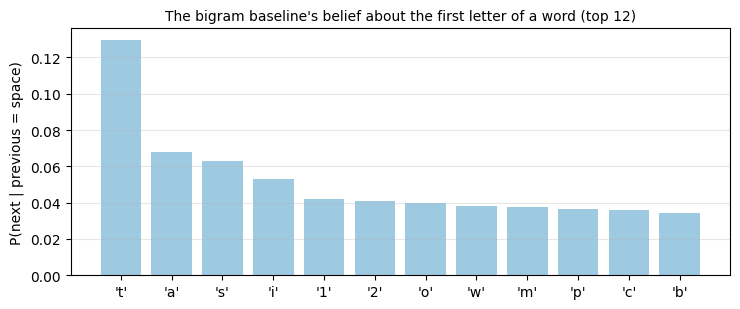

In [10]:
# WHAT/WHY: a complete, transparent baseline. Counting letter pairs in the training split gives
# P(next | previous); add-one smoothing stops any pair having probability exactly 0 (which would
# make the held-out perplexity infinite the first time an unseen pair appeared).
train_text, val_text = text[:int(0.8 * len(text))], text[int(0.8 * len(text)):]
bg_chars = sorted(set(text)); bg_i = {c: i for i, c in enumerate(bg_chars)}; Vb = len(bg_chars)

counts = np.ones((Vb, Vb))                       # row = previous character, column = next character
for a, b in zip(train_text, train_text[1:]):
    counts[bg_i[a], bg_i[b]] += 1
probs = counts / counts.sum(axis=1, keepdims=True)

def bigram_generate(seed, n=300, temperature=0.8):
    """Same sampling rule as lesson 01: scores / temperature -> softmax -> sample -> append."""
    out = seed
    for _ in range(n):
        logits = np.log(probs[bg_i[out[-1]]]) / temperature
        p = np.exp(logits - logits.max()); p /= p.sum()
        out += bg_chars[np.random.choice(Vb, p=p)]
    return out

def bigram_perplexity(s):
    """exp(mean negative log-probability of each character given the one before it)."""
    logp = [np.log(probs[bg_i[a], bg_i[b]]) for a, b in zip(s, s[1:])]
    return float(np.exp(-np.mean(logp)))

np.random.seed(0)
bigram_ppl = bigram_perplexity(val_text)
print(f"bigram baseline — held-out perplexity: {bigram_ppl:.2f}   (uniform guessing would be {Vb})")
print(f"\nT = 0.5 : {bigram_generate('the goalie ', temperature=0.5)[:160]}")
print(f"T = 1.2 : {bigram_generate('the goalie ', temperature=1.2)[:160]}")
print("\nRead these as the floor: a model that only counts pairs of letters already gets this far.")
print("Your LSTM sees 30 characters of context instead of one — Task 4 measures how much that buys.")

# One picture of what the baseline "knows": its belief about which character starts a word.
row = probs[bg_i[" "]]
order = np.argsort(row)[::-1][:12]
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.bar([repr(bg_chars[i]) for i in order], row[order], color="#9ecae1")
ax.set_ylabel("P(next | previous = space)")
ax.set_title("The bigram baseline's belief about the first letter of a word (top 12)", fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


## 📝 Summary

The worked example gave you a **baseline** (a counting bigram model with its held-out perplexity printed). The four tasks ask you to build the **learned** side yourself:

- Task 1 — a character vocabulary and next-character windows, split by position
- Task 2 — lesson 01's LSTM language model and its training loop, with a held-out loss per epoch
- Task 3 — temperature sampling, the same seed at T = 0.5 and T = 1.2
- Task 4 — perplexity against an untrained model, a training/held-out gap, an in-vocabulary rate, and three honest sentences

Once your gates pass, this notebook contains your own text-generation evidence: samples, losses, and numbers with their limits stated. Unit 2 examples 01, 05 and 06 contain every technique needed.

**Next steps:** Unit 3 applies the same "condition, then generate" idea to a retrieval-augmented question answerer.


## 📚 References & Further Reading

**Papers:**
- Hochreiter & Schmidhuber (1997) — *Long Short-Term Memory*, Neural Computation 9(8) — the recurrent unit inside `nn.LSTM`
- Graves (2013) — [Generating Sequences With Recurrent Neural Networks](https://arxiv.org/abs/1308.0850) — character-level generation with temperature-style sampling, the recipe this exercise follows
- Holtzman et al. (2020) — [The Curious Case of Neural Text Degeneration](https://arxiv.org/abs/1904.09751) — why low temperature loops and high temperature degrades, and the nucleus-sampling alternative

**In this unit:** example 01 (the model and the sampler), example 05 (temperature and top-k on literary text), example 06 (perplexity and its blind spots).
